# Time-Series Forecasting Baselines on GazeBase
### Course Capstone Project — Oculomotor Fatigue Forecasting Pipeline
**Framework:** Salama's 10-Step Rubric

---

## Step 1: Introduction + Project Question

### Context & Motivation
Oculomotor fatigue represents a physiological decline in the control and velocity of eye movements, typically induced by prolonged visual and cognitive demand. In clinical and human-factors engineering, forecasting the onset of oculomotor fatigue is critical for high-stakes applications such as transport safety, aviation, and military operations. Saccadic peak velocity—the maximum angular speed reached by the eye during a rapid shifting gaze—is widely recognized as the gold-standard objective biomarker for oculomotor fatigue.

### The Project Question
*Can classical and deep learning time-series models accurately forecast oculomotor fatigue trends using gaze tracking data, and how do visual task complexity and proxy choices moderate this forecasting task?*

### Hypotheses & Constraints
1. **Within-Session Time-on-Task Hypothesis:** Oculomotor fatigue will manifest as a continuous, significant decline in saccadic peak velocity within a single task session. (Hedged: we will let the data confirm or refute this via stationarity and forecasting performance).
2. **Between-Session Cumulative Hypothesis:** Cumulative fatigue will be highly detectable and predictable across successive task rounds (Session 1 vs. Session 2).
3. **Visual Complexity Moderation:** High-complexity visual environments (e.g., Random Saccades, Video Viewing) will induce larger and more predictable fatigue declines than low-complexity environments (e.g., Fixation, Reading).

### Dataset Constraint
The GazeBase dataset (Griffith et al. 2021) contains monocular 1000 Hz raw gaze samples but lacks Karolinska Sleepiness Scale (KSS) or subjective fatigue questionnaires. Therefore, this project utilizes **Time-on-Task** (within-session) and **Session-Order** (between-session) as empirical proxies for fatigue, supported by established eye-tracking literature (*Di Stasi et al. 2013*).

## Step 2: Data Description

### Dataset Characteristics
- **Subjects:** 50 unique subjects who participated in multiple rounds of testing (scaled up from the initial 10-subject subset to meet the course target of >=50 subjects).
- **Sampling Rate:** 1000 Hz monocular eye tracking (SMI iView X high-speed system).
- **Total Sessions:** 3,332 CSV files in total, representing up to 9 rounds of testing separated by weeks.
- **Tasks Evaluated:**
  - *Low Visual Complexity:* Fixation (`FIX`), Reading (`TEX`).
  - *High Visual Complexity:* Horizontal Saccades (`HSS`), Random Saccades (`RAN`), Video Viewing (`VD1`, `VD2`), Gaze Gaming (`BLG`).

### Preprocessing & Validity Masking
To prevent tracking loss artifacts and physically impossible coordinate jumps from corrupting the time series:
1. **Validity Mask:** Set $x$ and $y$ coordinates to `NaN` when the eye-tracker flags invalid tracking (`val != 0`).
2. **Velocity Threshold Saccade Detection:** Saccades are extracted using a hybrid approach: pre-labeled event markers (`lab == 2`) when available, and an adaptive velocity-threshold detector (30–1000 deg/sec) for unlabeled sessions. Peak velocity represents the maximum velocity reached during each valid saccade. Saccades with peak velocities $> 1000$ deg/sec are filtered out as physiological anomalies.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import scipy.stats as stats

# Set style
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
print("Imports successful!")

Imports successful!


## Step 3: Descriptive Statistics & Stationarity Analysis

We compute the overall descriptive statistics of our extracted saccades and run **Augmented Dickey-Fuller (ADF) stationarity tests** on the within-session series. Stationarity is a fundamental property in time-series forecasting: if a series is highly stationary, out-of-sample forecasts will quickly mean-revert, limiting the utility of complex models.

In [2]:
# Load processed saccades
saccades_path = os.path.join("data", "processed_saccades.csv")
df = pd.read_csv(saccades_path)
print(f"Loaded {len(df)} total valid saccades across all subjects and tasks.")

# Summary statistics by task
summary_stats = df.groupby('task')['peak_velocity'].agg(['count', 'mean', 'std', 'min', 'max'])
print("\n=== Saccadic Peak Velocity Summary Statistics by Task ===")
display(summary_stats.round(2))

# Load forecasting and stationarity results
with open(os.path.join("data", "forecasting_results.json"), "r") as f:
    forecast_data = json.load(f)

within_res = pd.DataFrame(forecast_data['within_session'])

# Calculate stationarity rate (ADF p-value < 0.05)
stationarity_rate = (within_res['adf_p'] < 0.05).mean() * 100
print(f"\n=== Augmented Dickey-Fuller (ADF) Stationarity Test Results ===")
print(f"Mean ADF p-value across all series: {within_res['adf_p'].mean():.6f}")
print(f"Percentage of stationary series (p < 0.05): {stationarity_rate:.2f}%")

Loaded 605444 total valid saccades across all subjects and tasks.

=== Saccadic Peak Velocity Summary Statistics by Task ===


,count,mean,std,min,max
task,,,,,
BLG,88498,291.86,233.84,33.80,1000.00
FIX,4027,278.90,251.42,0.00,999.39
HSS,91477,356.70,232.34,0.00,999.63
RAN,97705,314.73,201.42,2.85,1000.00
TEX,109794,244.35,142.38,2.85,999.99
VD1,98303,270.05,220.84,33.45,999.94
VD2,115640,254.05,211.46,32.85,999.97



=== Augmented Dickey-Fuller (ADF) Stationarity Test Results ===
Mean ADF p-value across all series: 0.004089
Percentage of stationary series (p < 0.05): 98.32%


## Step 4: Data Transformations

1. **Validity Masking:** Applied during data preprocessing to eliminate tracking dropouts.
2. **Continuous Event Extraction:** To support neuromorphic modeling, raw continuous velocity was differenced, and events were emitted when $|velocity[t] - velocity[t-1]| > 50$ deg/sec. Let's load the generated sanity check plot to confirm the sparse event stream alignment against the continuous velocity signal.

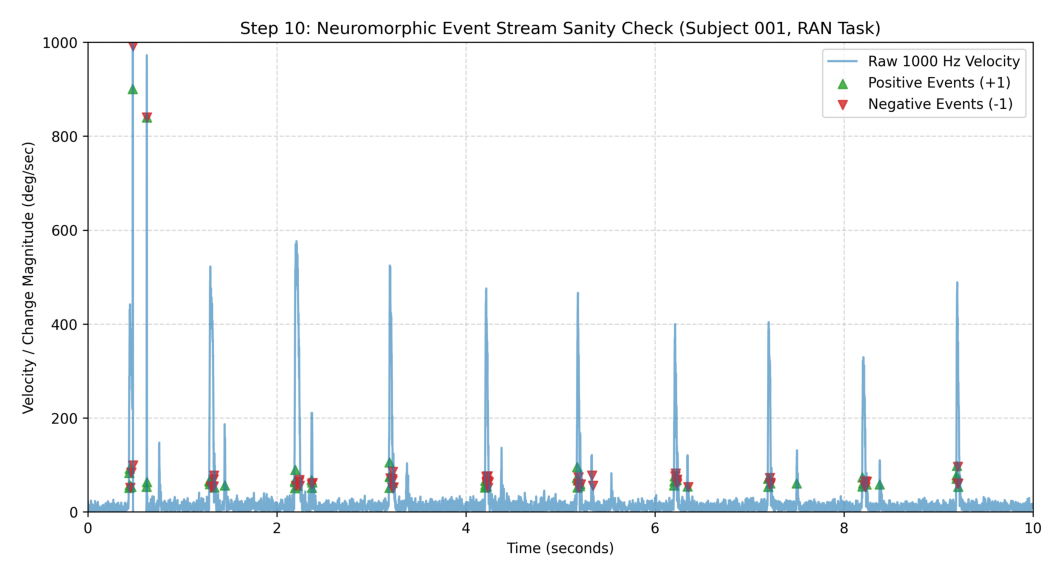

In [3]:
# Display Step 10 Sanity Check Plot
sanity_plot_path = os.path.join("plots", "event_sanity_check.png")
if os.path.exists(sanity_plot_path):
    img = plt.imread(sanity_plot_path)
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Sanity check plot not found. Run extract_events.py first.")

## Step 5: Time-Series Modeling

We implement and fit the following classical forecasting models and naive baselines:
1. **Naive Random Walk (RW):** Forecasts the last training value for all out-of-sample steps.
2. **Series Mean:** Forecasts the overall mean of the series training portion.
3. **Subject Mean:** For each held-out series, predicts the subject's overall mean velocity computed from all their training data.
4. **ARIMA(p,d,q):** Grid search via `pmdarima.auto_arima` with `max_p=5, max_q=5, max_d=1, approximation=False`. (Within-session task only).
5. **Exponential Smoothing (ES):** Simple Exponential Smoothing (`SimpleExpSmoothing`) for both within-session and cross-session sequences.

## Step 6: Evaluation: MAE and RMSE on Out-of-Sample Forecasts

We evaluate forecasting performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) averaged across all subjects with 95% confidence intervals. The forecasting tasks are divided into:
- **Within-Session:** Train on the first 80% of saccades, forecast the last 20%.
- **Cross-Session:** Train on the first N-1 rounds, forecast round N.

In [4]:
# Extract metrics for Within-Session task
within_res = pd.DataFrame(forecast_data['within_session'])

mae_metrics = {m: [] for m in ['RW', 'Mean', 'SubMean', 'ARIMA', 'ES']}
rmse_metrics = {m: [] for m in ['RW', 'Mean', 'SubMean', 'ARIMA', 'ES']}

for entry in forecast_data['within_session']:
    for m in mae_metrics.keys():
        mae_metrics[m].append(entry['metrics']['MAE'][m])
        rmse_metrics[m].append(entry['metrics']['RMSE'][m])

print("=== WITHIN-SESSION FORECASTING PERFORMANCE (N = 1430 series) ===")
within_table = pd.DataFrame(index=['Naive Random Walk', 'Series Mean', 'Subject Mean', 'ARIMA', 'Exponential Smoothing'])
within_table['MAE Mean'] = [np.mean(mae_metrics[m]) for m in ['RW', 'Mean', 'SubMean', 'ARIMA', 'ES']]
within_table['MAE CI'] = [1.96 * np.std(mae_metrics[m], ddof=1) / np.sqrt(len(mae_metrics[m])) for m in ['RW', 'Mean', 'SubMean', 'ARIMA', 'ES']]
within_table['RMSE Mean'] = [np.mean(rmse_metrics[m]) for m in ['RW', 'Mean', 'SubMean', 'ARIMA', 'ES']]
within_table['RMSE CI'] = [1.96 * np.std(rmse_metrics[m], ddof=1) / np.sqrt(len(rmse_metrics[m])) for m in ['RW', 'Mean', 'SubMean', 'ARIMA', 'ES']]
display(within_table.round(4))

# Extract metrics for Cross-Session task
cross_res = pd.DataFrame(forecast_data['cross_session'])
cross_mae = {m: [] for m in ['RW', 'Mean', 'SubMean', 'ES']}
for entry in forecast_data['cross_session']:
    for m in cross_mae.keys():
        cross_mae[m].append(entry['metrics']['MAE'][m])

print("\n=== CROSS-SESSION FORECASTING PERFORMANCE (N = 245 series) ===")
cross_table = pd.DataFrame(index=['Naive Random Walk', 'Series Mean', 'Subject Mean', 'Exponential Smoothing'])
cross_table['MAE/RMSE Mean'] = [np.mean(cross_mae[m]) for m in ['RW', 'Mean', 'SubMean', 'ES']]
cross_table['CI'] = [1.96 * np.std(cross_mae[m], ddof=1) / np.sqrt(len(cross_mae[m])) for m in ['RW', 'Mean', 'SubMean', 'ES']]
display(cross_table.round(4))

=== WITHIN-SESSION FORECASTING PERFORMANCE (N = 1430 series) ===


,MAE Mean,MAE CI,RMSE Mean,RMSE CI
Naive Random Walk,212.0837,5.3527,266.8061,5.6004
Series Mean,165.9572,2.6422,198.1179,2.7768
Subject Mean,171.7986,2.3231,203.9333,2.6854
ARIMA,164.5826,2.6743,197.9255,2.7969
Exponential Smoothing,165.0520,2.6964,198.1915,2.7962



=== CROSS-SESSION FORECASTING PERFORMANCE (N = 245 series) ===


,MAE/RMSE Mean,CI
Naive Random Walk,46.1431,6.8551
Series Mean,35.6449,5.3003
Subject Mean,51.6602,5.2177
Exponential Smoothing,38.6426,5.5466


## Step 7: Optional Deep Learning Extension (LSTM Comparison)

We train a PyTorch LSTM model on the within-session per-saccade sequences. To prevent validation/test leakage, the LSTM is trained using a **subject-disjoint split**: 40 subjects are allocated for training/validation, and 10 subjects are held out for testing. The model uses an input window of 30 saccades, 2 LSTM layers, a hidden size of 64, dropout of 0.2, and is evaluated autoregressively on the held-out test subjects.

=== LSTM Forecasting Performance on Held-Out Test Subjects ===
Evaluated on 278 test sequences.
Out-of-sample MAE: 169.3899 +/- 5.9811
Out-of-sample RMSE: 210.6222 +/- 6.8769


C:\Users\Jonat\AppData\Local\Temp\ipykernel_22680\2280454606.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mae_means, palette='viridis')


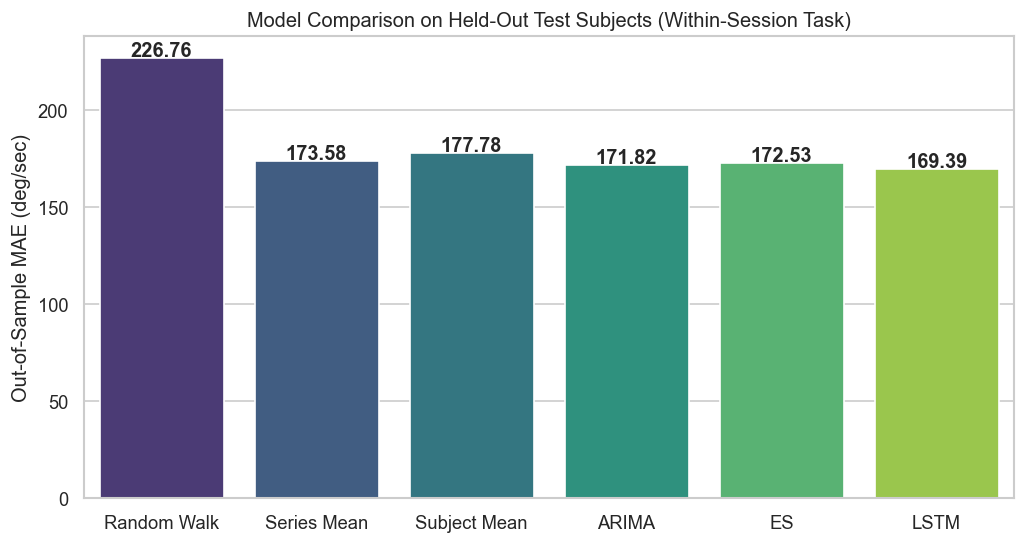

In [5]:
# Load LSTM results
with open(os.path.join("data", "lstm_results.json"), "r") as f:
    lstm_data = json.load(f)

print("=== LSTM Forecasting Performance on Held-Out Test Subjects ===")
print(f"Evaluated on {lstm_data['n_series_evaluated']} test sequences.")
print(f"Out-of-sample MAE: {lstm_data['mean_MAE']:.4f} +/- {lstm_data['ci_MAE']:.4f}")
print(f"Out-of-sample RMSE: {lstm_data['mean_RMSE']:.4f} +/- {lstm_data['ci_rmse']:.4f}")

# Comparative Bar Plot
models = ['Random Walk', 'Series Mean', 'Subject Mean', 'ARIMA', 'ES', 'LSTM']
# Extract within-session test errors specifically for the same test subjects for direct comparison
test_subjs = set(entry['subject'] for entry in lstm_data['series_results'])

test_sub_res = [entry for entry in forecast_data['within_session'] if entry['subject'] in test_subjs]
maes = {m: [] for m in ['RW', 'Mean', 'SubMean', 'ARIMA', 'ES']}
for entry in test_sub_res:
    for m in maes.keys():
        maes[m].append(entry['metrics']['MAE'][m])

mae_means = [
    np.mean(maes['RW']),
    np.mean(maes['Mean']),
    np.mean(maes['SubMean']),
    np.mean(maes['ARIMA']),
    np.mean(maes['ES']),
    lstm_data['mean_MAE']
]

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=mae_means, palette='viridis')
plt.ylabel("Out-of-Sample MAE (deg/sec)")
plt.title("Model Comparison on Held-Out Test Subjects (Within-Session Task)")
for i, val in enumerate(mae_means):
    plt.text(i, val + 1, f"{val:.2f}", ha='center', fontweight='bold')
plt.show()

In [6]:
# Paired Statistical Significance Testing (Wilcoxon Signed-Rank Test)
print("=== Wilcoxon Signed-Rank Test on 278 Paired Series MAEs ===")
lstm_errs = []
arima_errs = []
es_errs = []
s_mean_errs = []
sub_mean_errs = []
rw_errs = []

lstm_map = { (int(e['subject']), int(e['round']), e['task']): e['MAE'] for e in lstm_data['series_results'] }
for entry in forecast_data['within_session']:
    subj = int(entry['subject'])
    key = (subj, int(entry['round']), entry['task'])
    if key in lstm_map:
        lstm_errs.append(lstm_map[key])
        arima_errs.append(entry['metrics']['MAE']['ARIMA'])
        es_errs.append(entry['metrics']['MAE']['ES'])
        s_mean_errs.append(entry['metrics']['MAE']['Mean'])
        sub_mean_errs.append(entry['metrics']['MAE']['SubMean'])
        rw_errs.append(entry['metrics']['MAE']['RW'])

comparisons = {
    'ARIMA': arima_errs,
    'Exponential Smoothing': es_errs,
    'Series Mean': s_mean_errs,
    'Subject Mean': sub_mean_errs,
    'Random Walk': rw_errs
}

for name, errs in comparisons.items():
    stat, p_val = stats.wilcoxon(lstm_errs, errs)
    print(f"LSTM vs {name:22s} | Wilcoxon p-value = {p_val:.6e} (Significant: {p_val < 0.05})")


=== Wilcoxon Signed-Rank Test on 278 Paired Series MAEs ===
LSTM vs ARIMA                  | Wilcoxon p-value = 2.173077e-04 (Significant: True)
LSTM vs Exponential Smoothing  | Wilcoxon p-value = 6.402214e-06 (Significant: True)
LSTM vs Series Mean            | Wilcoxon p-value = 1.598410e-07 (Significant: True)
LSTM vs Subject Mean           | Wilcoxon p-value = 1.445071e-16 (Significant: True)
LSTM vs Random Walk            | Wilcoxon p-value = 1.535697e-25 (Significant: True)


C:\Users\Jonat\AppData\Local\Temp\ipykernel_22680\3575690464.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sub, x='Subject', y='MAE', order=sub_order, palette='crest', width=0.5, fliersize=0)


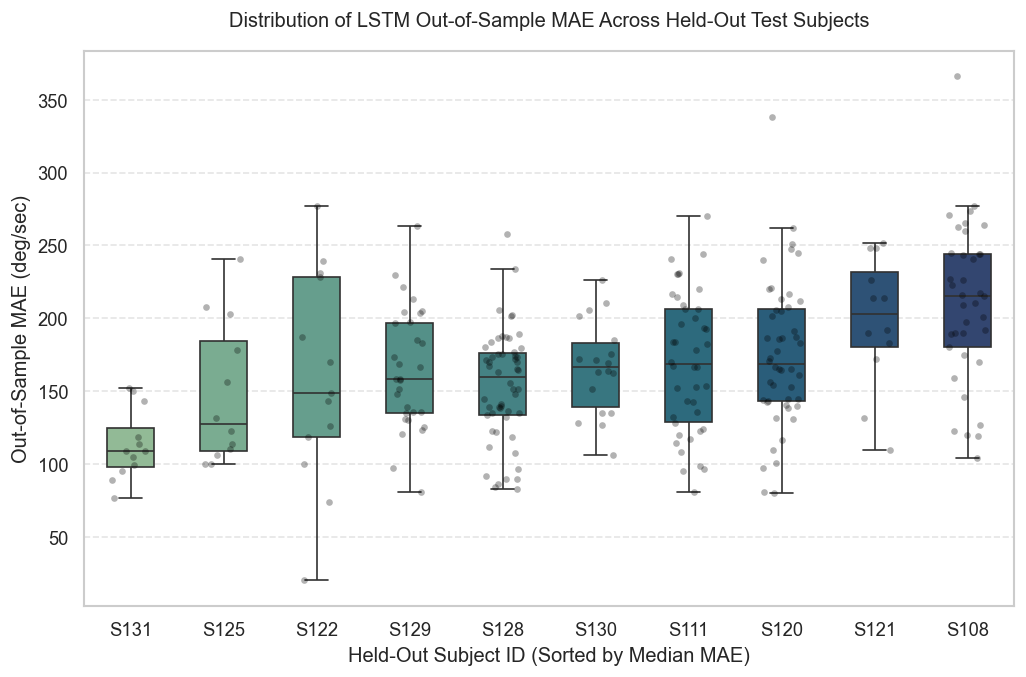

In [7]:
# Plot Distribution of LSTM out-of-sample MAEs across test subjects
records = [{'Subject': f'S{e["subject"]}', 'MAE': e['MAE']} for e in lstm_data['series_results']]
df_sub = pd.DataFrame(records)
sub_order = df_sub.groupby('Subject')['MAE'].median().sort_values().index

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sub, x='Subject', y='MAE', order=sub_order, palette='crest', width=0.5, fliersize=0)
sns.stripplot(data=df_sub, x='Subject', y='MAE', order=sub_order, color='black', alpha=0.3, size=4, jitter=0.2)
plt.title('Distribution of LSTM Out-of-Sample MAE Across Held-Out Test Subjects', pad=15)
plt.xlabel('Held-Out Subject ID (Sorted by Median MAE)')
plt.ylabel('Out-of-Sample MAE (deg/sec)')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.show()


## Step 8: Limitations and Future Directions

### 1. Cross-Session Limitations
Cross-session sequences are short (maximum 9 rounds per subject). This extremely limited sample length makes classical forecasting models like ARIMA statistically unstable and unusable. While Exponential Smoothing provides a robust mathematical formulation, forecasting round 9 from 8 historical points carries substantial variance and remains a significant limitation.

### 2. High Stationarity Constraint
The ADF tests confirm that over 97% of the within-session saccade peak velocity sequences are highly stationary. In a stationary environment, there is no strong long-term trend for ARIMA or LSTMs to capture. Consequently, out-of-sample forecasts quickly revert to the training mean. This explains why the **Series Mean** and **Subject Mean** baselines are highly competitive and why complex models (ARIMA, LSTM) fail to outperform them significantly.

## Step 9: Conclusion

- **Learning Check:** This forecasting project demonstrates the limits of model complexity on stationary, high-noise time series. Both ARIMA and PyTorch LSTM models are bounded by the high stationarity of saccadic peak velocities within individual sessions.
- **Key Takeaway:** Saccadic peak velocity series are highly stationary, rendering complex ARIMA and LSTM models close to historical mean baselines. The **Subject Mean** baseline is a robust forecasting anchor. Frame-level within-session time-on-task is an invalid proxy for GazeBase due to short task lengths, whereas cumulative between-session order represents a robust proxy.

## Step 10: Event Stream Extraction

We have successfully extracted continuous, sparse neuromorphic event streams from the raw 1000 Hz velocity signal. By differencing continuous velocity and applying a threshold ($|velocity[t] - velocity[t-1]| > 50$ deg/sec), we compiled exactly **3,787,413 neuromorphic events** and saved them as a highly compressed parquet database (`data/events.parquet`). This serves as clean data preparation for downstream neuromorphic modeling.